<a href="https://colab.research.google.com/github/Nico859a/GB885_Final_Project_Potenza_N/blob/main/GB885_Final_Project_Potenza_N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Rush Sportswear Analysis**
Final Project

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data Acquisition

In [2]:
# read csv files from github
url = 'https://raw.githubusercontent.com/Nico859a/GB885_Final_Project_Potenza_N/refs/heads/main/TABLE_PRODUCTS_885.csv'
products_df = pd.read_csv(url, sep = '|')
products_df.head()

,PRODUCT_ID,PRODUCT_NAME
0,20,Men's Street Footwear
1,30,Men's Athletic Footwear
2,120,Women's Street Footwear
3,130,Women's Athletic Footwear
4,40,Men's Apparel


In [3]:
url = 'https://raw.githubusercontent.com/Nico859a/GB885_Final_Project_Potenza_N/refs/heads/main/TABLE_RETAILER_885.csv'
retailer_df = pd.read_csv(url)
retailer_df.head()

,RETAILER_ID,RETAILER,REGION,STATE,CITY
0,A00MOHCO,Amazon,Midwest,Ohio,Columbus
1,A00NMAPO,Amazon,Northeast,Maine,Portland
2,A00NMABO,Amazon,Northeast,Massachusetts,Boston
3,A00NNEMA,Amazon,Northeast,New Hampshire,Manchester
4,A00NVEBU,Amazon,Northeast,Vermont,Burlington


In [4]:
url = 'https://raw.githubusercontent.com/Nico859a/GB885_Final_Project_Potenza_N/refs/heads/main/TABLE_SALES_885.csv'
sales_df = pd.read_csv(url)
sales_df.head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
0,1,A00MOHCO,1/1/2020,1,1,2020,20,50.0,1200,0.5,In-store
1,7,A00MOHCO,1/7/2020,1,7,2020,20,50.0,1250,0.5,In-store
2,13,A00MOHCO,1/25/2020,1,25,2020,20,50.0,1220,0.5,Outlet
3,19,A00MOHCO,1/31/2020,1,31,2020,20,50.0,1200,0.5,Outlet
4,25,A00MOHCO,2/6/2020,2,6,2020,20,60.0,1220,0.5,Outlet



## Inspect Data

In [5]:
# inspect data
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   PRODUCT_ID    6 non-null      int64 
 1   PRODUCT_NAME  6 non-null      object
dtypes: int64(1), object(1)
memory usage: 228.0+ bytes


In [6]:
retailer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   RETAILER_ID  110 non-null    object
 1   RETAILER     110 non-null    object
 2   REGION       110 non-null    object
 3   STATE        110 non-null    object
 4   CITY         110 non-null    object
dtypes: object(5)
memory usage: 4.4+ KB


In [7]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDER_ID          9648 non-null   int64  
 1   RETAILER_ID       9648 non-null   object 
 2   INVOICE_DATE      9648 non-null   object 
 3   MONTH             9648 non-null   int64  
 4   DAY               9648 non-null   int64  
 5   YEAR              9648 non-null   int64  
 6   PRODUCT_ID        9648 non-null   int64  
 7   PRICE_PER_UNIT    9646 non-null   float64
 8   UNITS_SOLD        9648 non-null   object 
 9   OPERATING_MARGIN  9648 non-null   float64
 10  SALES_METHOD      9648 non-null   object 
dtypes: float64(2), int64(5), object(4)
memory usage: 829.3+ KB


In [8]:
products_df.isnull().sum()

,0
PRODUCT_ID,0
PRODUCT_NAME,0


In [9]:
retailer_df.isnull().sum()

,0
RETAILER_ID,0
RETAILER,0
REGION,0
STATE,0
CITY,0


In [10]:
sales_df.isnull().sum()

,0
ORDER_ID,0
RETAILER_ID,0
INVOICE_DATE,0
MONTH,0
DAY,0
YEAR,0
PRODUCT_ID,0
PRICE_PER_UNIT,2
UNITS_SOLD,0
OPERATING_MARGIN,0


In [11]:
# inspect for non-trad categorical data
# identify by viewing unique values in all categorical fields
# list  of categorical variables in dataframes

for df in [products_df, retailer_df, sales_df]:
    cat_var = list(df.select_dtypes(include=['object']).columns)
    for column in cat_var:
        print(column)
        print(df[column].unique())

PRODUCT_NAME
["Men's Street Footwear" "Men's Athletic Footwear"
 "Women's Street Footwear" "Women's Athletic Footwear" "Men's Apparel"
 "Women's Apparel"]
RETAILER_ID
['A00MOHCO' 'A00NMAPO' 'A00NMABO' 'A00NNEMA' 'A00NVEBU' 'A00SALBI'
 'A00SKELO' 'A00SNOCH' 'A00WALAN' 'F00MILCH' 'F00MIODE' 'F00MKAWI'
 'F00MMIDE' 'F00MMIMI' 'F00MMIST' 'F00MNEOM' 'F00MNOFA' 'F00MSOSI'
 'F00NCOHA' 'F00NDEWI' 'F00NMABA' 'F00NNEMA' 'F00NNENE' 'F00NPEPH'
 'F00NRHPR' 'F00NWECH' 'F00SLONE' 'F00SMIJA' 'F00STEKN' 'F00STEDA'
 'F00SFLMI' 'F00SGEAT' 'F00SKELO' 'F00SSOCH' 'F00SVIRI' 'F00WALAN'
 'F00WARPH' 'F00WCALO' 'F00WHAHO' 'F00WIDBO' 'F00WWASE' 'F00WWYCH'
 'K00MKAWI' 'K00MMIMI' 'K00MMOBI' 'K00NDEWI' 'K00NNENE' 'K00NNEAL'
 'K00SOKOK' 'K00WARPH' 'K00WCALO' 'K00WCASA' 'K00WNEAL' 'K00WWYCH'
 'S00MILCH' 'S00MMIDE' 'S00MMOBI' 'S00MNEOM' 'S00MNOFA' 'S00MSOSI'
 'S00NCOHA' 'S00NMABA' 'S00NMABO' 'S00NNENE' 'S00NRHPR' 'S00SALBI'
 'S00SMIJA' 'S00STEKN' 'S00STEDA' 'S00STEHO' 'S00SFLMI' 'S00SFLOR'
 'S00SGEAT' 'S00SNOCH' 'S00SS

In [12]:
# inspect for other non-trad numeric values
sales_df.describe()

,ORDER_ID,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,OPERATING_MARGIN
count,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000,9646.000000,9648.000000
mean,4824.500000,6.458126,14.696310,2020.865050,79.975124,55.575264,0.422991
std,2785.282032,3.454799,7.348019,0.341688,50.668992,1017.819943,0.097197
min,1.000000,1.000000,1.000000,2020.000000,20.000000,7.000000,0.100000
25%,2412.750000,3.000000,9.000000,2021.000000,30.000000,35.000000,0.350000
50%,4824.500000,6.000000,15.000000,2021.000000,40.000000,45.000000,0.410000
75%,7236.250000,9.000000,21.000000,2021.000000,130.000000,55.000000,0.490000
max,9648.000000,12.000000,31.000000,2021.000000,140.000000,99999.000000,0.800000


In [13]:
# check for duplicates
for df in [sales_df, products_df, retailer_df]:
    print(df.duplicated().sum())

0
0
0


In [14]:
# check for erroneous values
for df in [products_df, retailer_df, sales_df]:
    cat_var = list(df.select_dtypes(include=['object']).columns)
    for column in cat_var:
        print(column)
        print(df[column].value_counts())

PRODUCT_NAME
PRODUCT_NAME
Men's Street Footwear        1
Men's Athletic Footwear      1
Women's Street Footwear      1
Women's Athletic Footwear    1
Men's Apparel                1
Women's Apparel              1
Name: count, dtype: int64
RETAILER_ID
RETAILER_ID
W00SFLOR    2
S00NNENE    2
W00SARLI    2
W00STEHO    2
A00NVEBU    1
           ..
W00WIDBO    1
W00WNELA    1
W00WORPO    1
W00WUTSA    1
W00WWASE    1
Name: count, Length: 106, dtype: int64
RETAILER
RETAILER
Foot Locker      33
Sports Direct    26
West Gear        24
Kohl's           12
Amazon            9
Walmart           6
Name: count, dtype: int64
REGION
REGION
Northeast    28
Midwest      24
West         24
South        18
Southeast    16
Name: count, dtype: int64
STATE
STATE
Florida           6
New York          5
Texas             5
California        4
Idaho             3
Mississippi       3
Maryland          3
Hawaii            3
Alaska            2
Illinois          2
Massachusetts     2
New Hampshire     2
Vermont  

In [15]:
# check for outliers
# write a function to calculate IQR and print rows with values that fall outside that IQR

def count_iqr_outliers(df, column):
    # define q1
    q1 = df[column].quantile(0.25)
    # define q3
    q3 = df[column].quantile(0.75)
    # define iqr
    iqr = q3 - q1
    # define outlier thresholds
    l_threshold = q1 - 1.5 * iqr
    u_threshold = q3 + 1.5 * iqr
    # count outliers
    outliers = (df[column] < l_threshold) | (df[column] > u_threshold)
    # Count the number of True values (outliers)
    return outliers.sum()

In [16]:
# iterate over numerical colums of dataframes
for df in [sales_df, products_df, retailer_df]:
    for column in df.select_dtypes(include=['int64', 'float64']).columns:
        print(column, count_iqr_outliers(df, column))

ORDER_ID 0
MONTH 0
DAY 0
YEAR 1302
PRODUCT_ID 0
PRICE_PER_UNIT 82
OPERATING_MARGIN 44
PRODUCT_ID 0


## Clean Data

In [17]:
# Convert INVOICE_DATE to datetime
sales_df['INVOICE_DATE'] = pd.to_datetime(sales_df['INVOICE_DATE'])

# drop redundant date columns
sales_df = sales_df.drop(columns=['MONTH', 'DAY', 'YEAR'])

In [18]:
# convert UNITS_SOLD in sales_df to int
# check UNITS_SOLD values
to_numeric = [
              'UNITS_SOLD'
             ]

for column in to_numeric:
    print(sales_df[column].unique())


['1200' '1250' '1220' '1275' '1150' '900' '850' '875' '925' '950' '800'
 '775' '825' '975' '1025' '700' '750' '475' '525' '495' '450' '500' '575'
 '550' '425' '400' '725' '675' '625' '445' '470' '375' '600' '1050' '1100'
 '1070' '1075' '1125' '1000' '350' '650' '420' '325' '300' '545' '570'
 '870' '820' '770' '795' '620' '670' '1020' '1045' '920' '945' '520' '720'
 '745' '645' '595' '336' '313' '354' '317' '319' '360' '299' '312' '234'
 '213' '254' '268' '238' '255' '240' '209' '223' '230' '228' '252' '273'
 '277' '241' '236' '263' '293' '203' '225' '216' '208' '270' '224' '231'
 '124' '158' '144' '122' '134' '135' '161' '149' '115' '112' '150' '189'
 '176' '182' '195' '181' '156' '111' '119' '120' '136' '145' '143' '104'
 '113' '160' '218' '210' '174' '138' '155' '196' '123' '131' '165' '202'
 '162' '137' '117' '167' '239' '217' '188' '256' '290' '304' '284' '244'
 '323' '116' '106' '98' '91' '173' '169' '180' '215' '233' '200' '105'
 '118' '94' '84' '163' '206' '175' '140' '127' '147

In [19]:
# PRICE_PER_UNIT has nulls
# convert '***' values to NaN
sales_df['UNITS_SOLD'] = pd.to_numeric(sales_df['UNITS_SOLD'], errors='coerce')

# drop the row if either UNITS_SOLD or PRICE_PER_UNIT is NaN
sales_df = sales_df.dropna(subset=['UNITS_SOLD', 'PRICE_PER_UNIT'])

# convert UNITS_SOLD to int
sales_df['UNITS_SOLD'] = sales_df['UNITS_SOLD'].astype(int)

In [20]:
# check change
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9644 entries, 0 to 9647
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ORDER_ID          9644 non-null   int64         
 1   RETAILER_ID       9644 non-null   object        
 2   INVOICE_DATE      9644 non-null   datetime64[ns]
 3   PRODUCT_ID        9644 non-null   int64         
 4   PRICE_PER_UNIT    9644 non-null   float64       
 5   UNITS_SOLD        9644 non-null   int64         
 6   OPERATING_MARGIN  9644 non-null   float64       
 7   SALES_METHOD      9644 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(2)
memory usage: 678.1+ KB


In [21]:
# fix typo in SALES_METHOD column
sales_df['SALES_METHOD'] = sales_df['SALES_METHOD'].replace('Ootlet', 'Outlet')
print(sales_df['SALES_METHOD'].unique())

['In-store' 'Outlet' 'Online']


In [22]:
# identified "999999999" RETAILER_ID
# inspect rows with RETAILER_ID of 999999999 to determine if we can drop
sales_df[sales_df['RETAILER_ID'].astype(str) == '999999999']

,ORDER_ID,RETAILER_ID,INVOICE_DATE,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
1446,8668,999999999,2021-07-23,20,60.0,298,0.42,Outlet


In [23]:
# drop the invalid RETAILER_ID row
sales_df = sales_df.drop(sales_df[sales_df['RETAILER_ID'] == '999999999'].index)

In [24]:
# windsorize the outlier data (clip at 95th percentile)
num_var = ['PRICE_PER_UNIT', 'OPERATING_MARGIN', 'UNITS_SOLD']

for column in num_var:
    # set upper clipping threshold
    high_percentile_value = sales_df[column].quantile(0.95)
    # clip upper outliers
    sales_df.loc[:, column] = sales_df[column].clip(upper=high_percentile_value)
    # set clipping threshold
    low_percentile_value = sales_df[column].quantile(0.05)
    # clip outliers
    sales_df.loc[:, column] = sales_df[column].clip(lower=low_percentile_value)

## Perform analysis

In [40]:
products_df.describe().T

,count,mean,std,min,25%,50%,75%,max
PRODUCT_ID,6.0,80.0,55.497748,20.0,32.5,80.0,127.5,140.0


In [41]:
retailer_df.describe().T

,count,unique,top,freq
RETAILER_ID,110,106,W00SFLOR,2
RETAILER,110,6,Foot Locker,33
REGION,110,5,Northeast,28
STATE,110,50,Florida,6
CITY,110,52,Charleston,4


In [42]:
sales_df.describe().T

,count,mean,min,25%,50%,75%,max,std
ORDER_ID,9643.0,4824.456082,1.0,2413.5,4824.0,7235.5,9648.0,2784.765044
INVOICE_DATE,9643,2021-05-10 16:35:08.555428864,2020-01-01 00:00:00,2021-02-17 00:00:00,2021-06-04 00:00:00,2021-09-16 00:00:00,2021-12-31 00:00:00,NaN
PRODUCT_ID,9643.0,80.006222,20.0,30.0,120.0,130.0,140.0,50.663713
PRICE_PER_UNIT,9643.0,45.0084,22.0,35.0,45.0,55.0,70.0,13.197777
UNITS_SOLD,9643.0,251.099658,47.0,106.0,176.0,350.0,725.0,195.470414
OPERATING_MARGIN,9643.0,0.421893,0.25,0.35,0.41,0.49,0.6,0.090406


In [25]:
# merge dataframes
merged_df = sales_df.merge(products_df, on='PRODUCT_ID').merge(retailer_df, on='RETAILER_ID')

In [45]:
# create total_sales and profit columns to better answer VP's questions
merged_df['TOTAL_SALES'] = merged_df['UNITS_SOLD'] * merged_df['PRICE_PER_UNIT']
merged_df['PROFIT'] = merged_df['TOTAL_SALES'] * merged_df['OPERATING_MARGIN']

In [46]:
# check changes
merged_df.head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,PRODUCT_NAME,RETAILER,REGION,STATE,CITY,TOTAL_SALES,PROFIT
0,1,A00MOHCO,2020-01-01,20,50.0,725,0.5,In-store,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus,36250.0,18125.0
1,7,A00MOHCO,2020-01-07,20,50.0,725,0.5,In-store,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus,36250.0,18125.0
2,13,A00MOHCO,2020-01-25,20,50.0,725,0.5,Outlet,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus,36250.0,18125.0
3,19,A00MOHCO,2020-01-31,20,50.0,725,0.5,Outlet,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus,36250.0,18125.0
4,25,A00MOHCO,2020-02-06,20,60.0,725,0.5,Outlet,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus,43500.0,21750.0


#### Q1: What product category (product) had the highest sales (in dollars) in 2021? How much did it sell?

In [28]:
# Q1: What product category (product) had the highest sales (in dollars) in 2021? How much did it sell?
q1_data = merged_df[merged_df['INVOICE_DATE'].dt.year == 2021].groupby('PRODUCT_NAME')['TOTAL_SALES'].sum().sort_values(ascending=False)
q1_data

,TOTAL_SALES
PRODUCT_NAME,
Men's Street Footwear,22276357.0
Women's Apparel,18887715.0
Men's Athletic Footwear,16303125.0
Women's Street Footwear,13712948.0
Men's Apparel,13184075.0
Women's Athletic Footwear,11426742.0


<Axes: xlabel='TOTAL_SALES', ylabel='PRODUCT_NAME'>

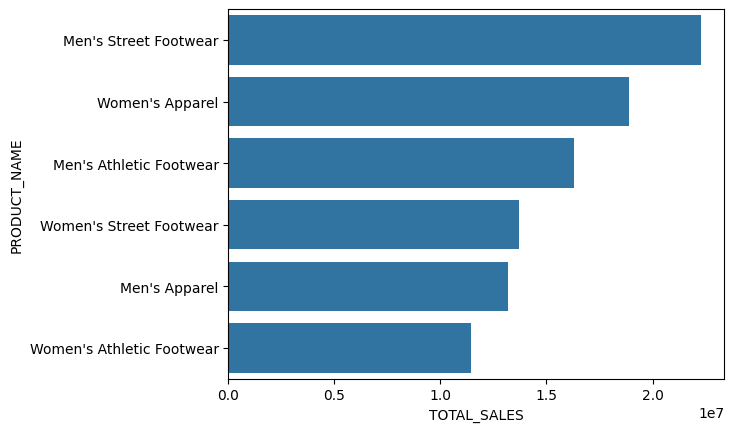

In [29]:
sns.barplot(data=q1_data.reset_index(), x='TOTAL_SALES', y='PRODUCT_NAME')

#### Q2: What state had the highest sales (in dollars) of women's products in 2021, and how much was it?

In [30]:
# Q2: What state had the highest sales (in dollars) of women's products in 2021, and how much was it?
q2_data = merged_df[(merged_df['INVOICE_DATE'].dt.year == 2021) & (merged_df['PRODUCT_NAME'].str.contains('Women'))].groupby('STATE')['TOTAL_SALES'].sum().sort_values(ascending=False)
q2_data

,TOTAL_SALES
STATE,
Maine,2082813.0
Delaware,1945850.0
New Hampshire,1856015.0
New York,1747275.0
Arizona,1733560.0
Illinois,1727790.0
Virginia,1672750.0
Nebraska,1653180.0
Missouri,1566173.0


<Axes: xlabel='TOTAL_SALES', ylabel='STATE'>

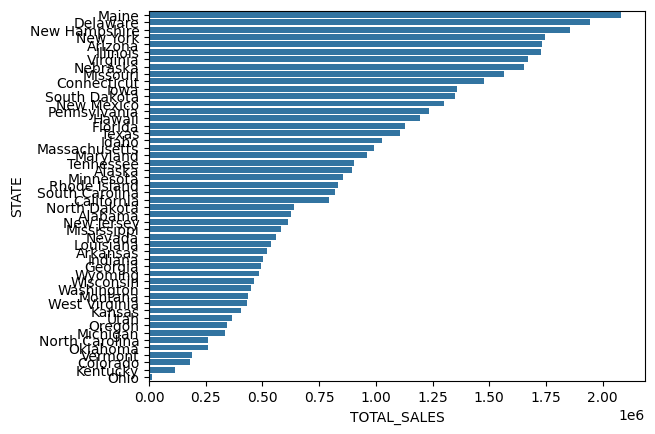

In [31]:
sns.barplot(data=q2_data.reset_index(), x='TOTAL_SALES', y='STATE')

#### Q3: What state had the highest sales (in dollars) of men's products in 2021, and how much was it?

In [32]:
# Q3: What state had the highest sales (in dollars) of men's products in 2021, and how much was it?
q3_data = merged_df[(merged_df['INVOICE_DATE'].dt.year == 2021) & (merged_df['PRODUCT_NAME'].str.contains('Men'))].groupby('STATE')['TOTAL_SALES'].sum().sort_values(ascending=False)
q3_data

,TOTAL_SALES
STATE,
Arizona,2195900.0
New Hampshire,2192300.0
Delaware,2123550.0
New York,2084216.0
Illinois,1976895.0
Maine,1972378.0
Missouri,1714014.0
Connecticut,1709665.0
New Mexico,1708712.0


<Axes: xlabel='TOTAL_SALES', ylabel='STATE'>

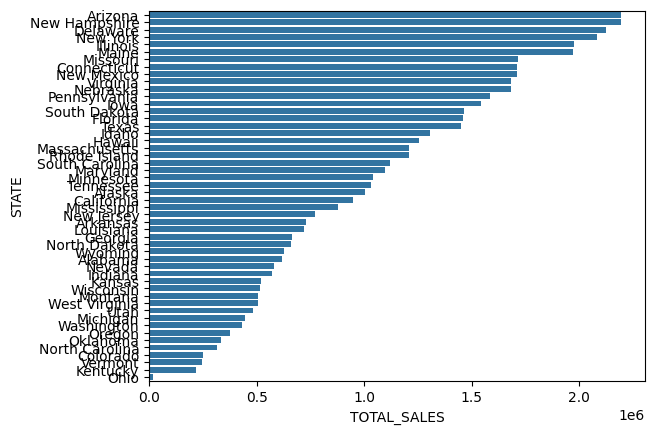

In [33]:
sns.barplot(data=q3_data.reset_index(), x='TOTAL_SALES', y='STATE')

#### Q4: What retailer purchased the most units in 2021? In 2020?

In [34]:
# Q4: What retailer purchased the most units in 2021? In 2020?
# for 2020
q4_data_2020 = merged_df[merged_df['INVOICE_DATE'].dt.year == 2020].groupby('RETAILER')['UNITS_SOLD'].sum().sort_values(ascending=False)
q4_data_2020


,UNITS_SOLD
RETAILER,
Amazon,283504
Kohl's,68701
West Gear,57334
Sports Direct,18880


In [35]:
# for 2021
q4_data_2021 = merged_df[merged_df['INVOICE_DATE'].dt.year == 2021].groupby('RETAILER')['UNITS_SOLD'].sum().sort_values(ascending=False)
q4_data_2021

,UNITS_SOLD
RETAILER,
Foot Locker,1076904
West Gear,318238
Sports Direct,257761
Amazon,198017
Kohl's,137541
Walmart,60170


<Axes: xlabel='UNITS_SOLD', ylabel='RETAILER'>

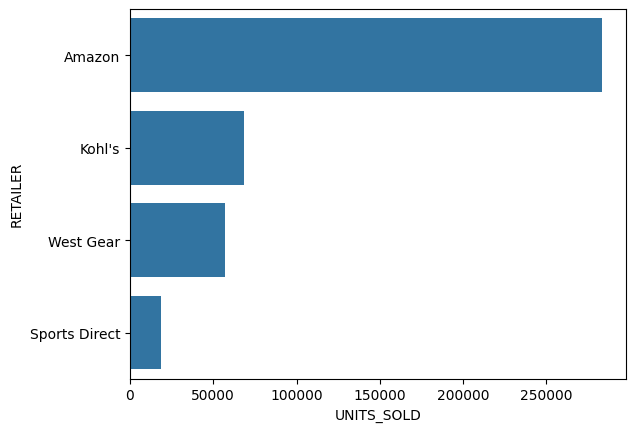

In [36]:
# 2020 chart
sns.barplot(data=q4_data_2020.reset_index(), x='UNITS_SOLD', y='RETAILER')

<Axes: xlabel='UNITS_SOLD', ylabel='RETAILER'>

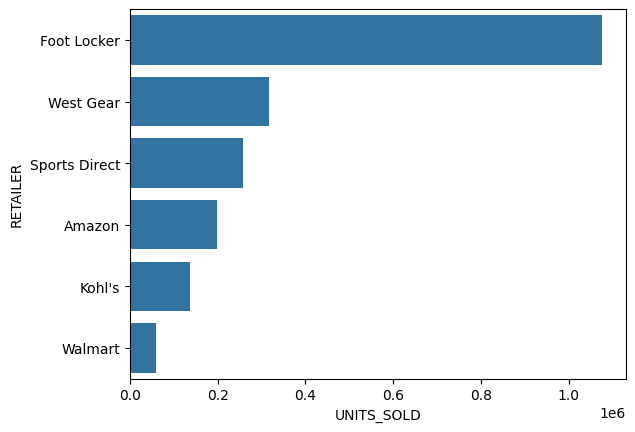

In [37]:
# 2021 chart
sns.barplot(data=q4_data_2021.reset_index(), x='UNITS_SOLD', y='RETAILER')

### Insights & Trends

In [47]:
# find avg profit per category
avg_profit = merged_df.groupby('PRODUCT_NAME')['PROFIT'].mean().sort_values(ascending=False)
avg_profit

,PROFIT
PRODUCT_NAME,
Men's Street Footwear,6535.204432
Women's Apparel,5537.350933
Men's Athletic Footwear,4345.339498
Women's Street Footwear,3809.778037
Men's Apparel,3772.210334
Women's Athletic Footwear,3326.836292


<Axes: xlabel='PROFIT', ylabel='PRODUCT_NAME'>

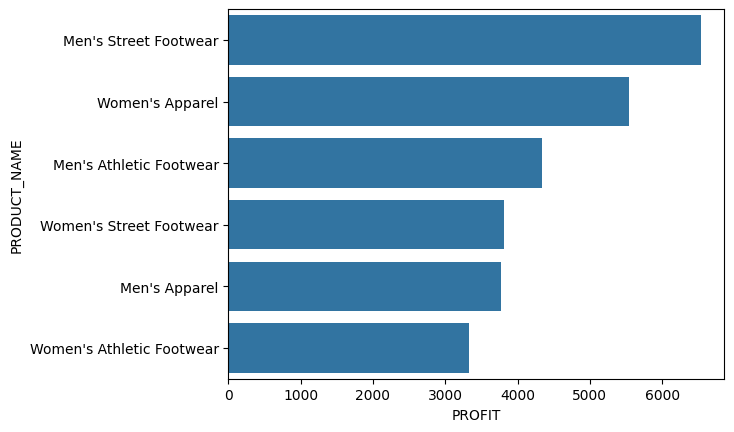

In [49]:
sns.barplot(data=avg_profit.reset_index(), x='PROFIT', y='PRODUCT_NAME')

In [50]:
# total sales by method
sales_method = merged_df.groupby('SALES_METHOD')['TOTAL_SALES'].sum().sort_values(ascending=False)
sales_method

,TOTAL_SALES
SALES_METHOD,
Online,46034576.0
Outlet,37950508.0
In-store,33845655.0


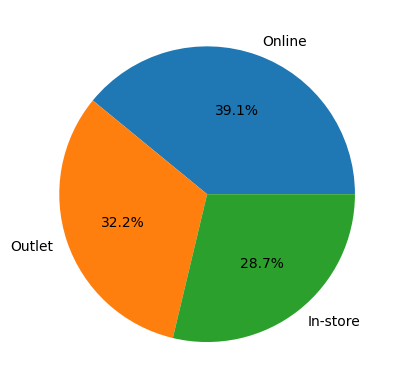

In [52]:
sales_method.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.show()

In [57]:
# look at sales and units sold per region by year
region_trends = merged_df.groupby(['REGION', merged_df['INVOICE_DATE'].dt.year]).agg(
    total_sales =('TOTAL_SALES', 'sum'),
    units_sold =('UNITS_SOLD', 'sum'),
    avg_price =('PRICE_PER_UNIT', 'mean'),
    order_count =('ORDER_ID', 'count'))
region_trends

total_sales  units_sold  avg_price  order_count
REGION    INVOICE_DATE                                                 
Midwest   2020            5376907.0      108702  51.687764          237
          2021           23957364.0      498532  45.454378         1633
Northeast 2020            6847174.0      119090  56.054795          292
          2021           31077627.0      653230  46.289523         2138
South     2020            1118316.0       17408  63.051948           77
          2021           10302379.0      243172  40.980769         2028
Southeast 2020            4831465.0       90638  48.559701          268
          2021            9954295.0      229804  40.526638         1145
West      2020            3865915.0       92581  43.117371          426
          2021           20499297.0      423893  44.998022         2022

<Axes: xlabel='REGION', ylabel='total_sales'>

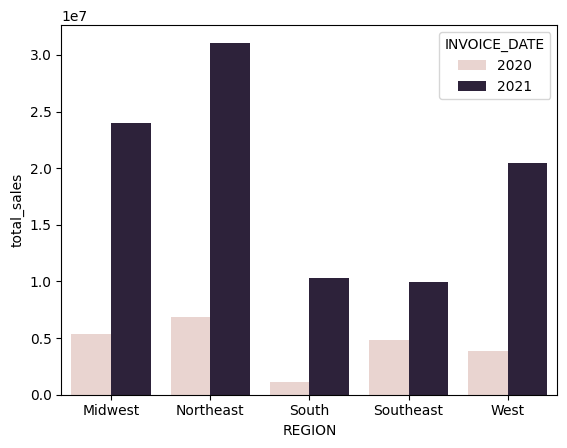

In [59]:
sns.barplot(data=region_trends.reset_index(), x='REGION', y='total_sales', hue='INVOICE_DATE')

In [60]:
# relationship between sales method and region
method_by_region = merged_df.pivot_table(index='REGION', columns='SALES_METHOD', values='TOTAL_SALES', aggfunc='sum')
method_by_region

SALES_METHOD,In-store,Online,Outlet
REGION,,,
Midwest,11711390.0,10782193.0,6840688.0
Northeast,6224905.0,18815198.0,12884698.0
South,2068875.0,8220563.0,1131257.0
Southeast,7152725.0,3663482.0,3969553.0
West,6687760.0,4553140.0,13124312.0


<Axes: xlabel='REGION'>

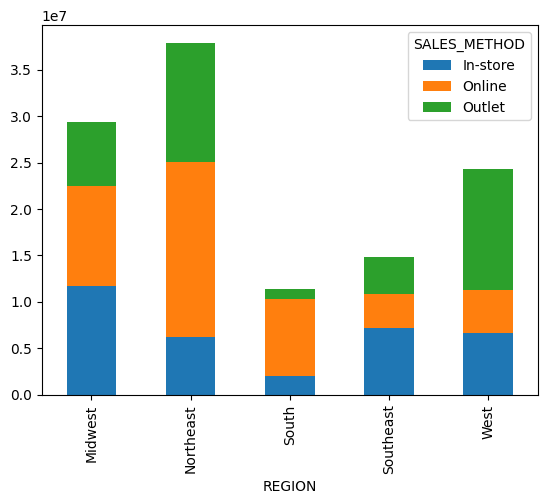

In [70]:
method_by_region.plot(kind='bar', stacked=True)

In [73]:
monthly_category_sales = merged_df.groupby([merged_df['INVOICE_DATE'].dt.month, 'PRODUCT_NAME'])['TOTAL_SALES'].sum().unstack()
monthly_category_sales

PRODUCT_NAME,Men's Apparel,Men's Athletic Footwear,Men's Street Footwear,Women's Apparel,Women's Athletic Footwear,Women's Street Footwear
INVOICE_DATE,,,,,,
1,1391489.0,1725092.0,1953516.0,1748811.0,1159958.0,1470927.0
2,1251150.0,1465847.0,1870987.0,1390179.0,991947.0,1261463.0
3,1022943.0,1320795.0,1715657.0,1338922.0,975855.0,1196899.0
4,1325468.0,1559538.0,2039289.0,1948503.0,1102425.0,1408255.0
5,1526380.0,1677804.0,2407315.0,2242616.0,1267520.0,1494898.0
6,1215027.0,1490635.0,2213673.0,2091270.0,1145068.0,1364988.0
7,1660809.0,2017783.0,2768436.0,2376651.0,1394619.0,1625680.0
8,1580458.0,2321175.0,2690027.0,2069224.0,1456513.0,1806283.0
9,1380124.0,1873587.0,2252172.0,1922566.0,1220555.0,1514370.0


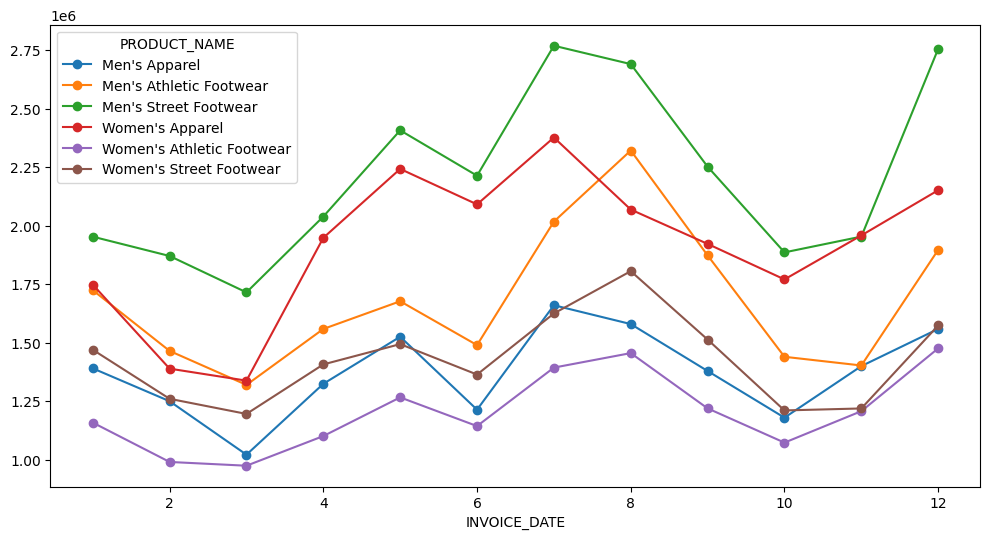

In [75]:
monthly_category_sales.plot(kind='line', marker='o', figsize=(12, 6))
plt.show()

In [77]:
# total sales by state
sales_by_state = merged_df.groupby('STATE')['TOTAL_SALES'].sum().nlargest(10)

,TOTAL_SALES
STATE,
Vermont,5144718.0
Maine,5118316.0
Ohio,4700308.0
New York,4100448.0
Kentucky,4083485.0
Delaware,4069400.0
New Hampshire,4048315.0
Arizona,3929460.0
Illinois,3715673.0


In [81]:
# what are the warmer weather top states buying
cat_by_warm_state = merged_df[merged_df['STATE'].isin(['Kentucky', 'Arizona', 'Virginia'])].groupby(['STATE', 'PRODUCT_NAME'])['TOTAL_SALES'].sum().unstack()
cat_by_warm_state

PRODUCT_NAME,Men's Apparel,Men's Athletic Footwear,Men's Street Footwear,Women's Apparel,Women's Athletic Footwear,Women's Street Footwear
STATE,,,,,,
Arizona,451700.0,680375.0,1063825.0,722750.0,438410.0,572400.0
Kentucky,716125.0,670000.0,809575.0,759875.0,566410.0,561500.0
Virginia,397035.0,593703.0,692729.0,689649.0,420008.0,563093.0


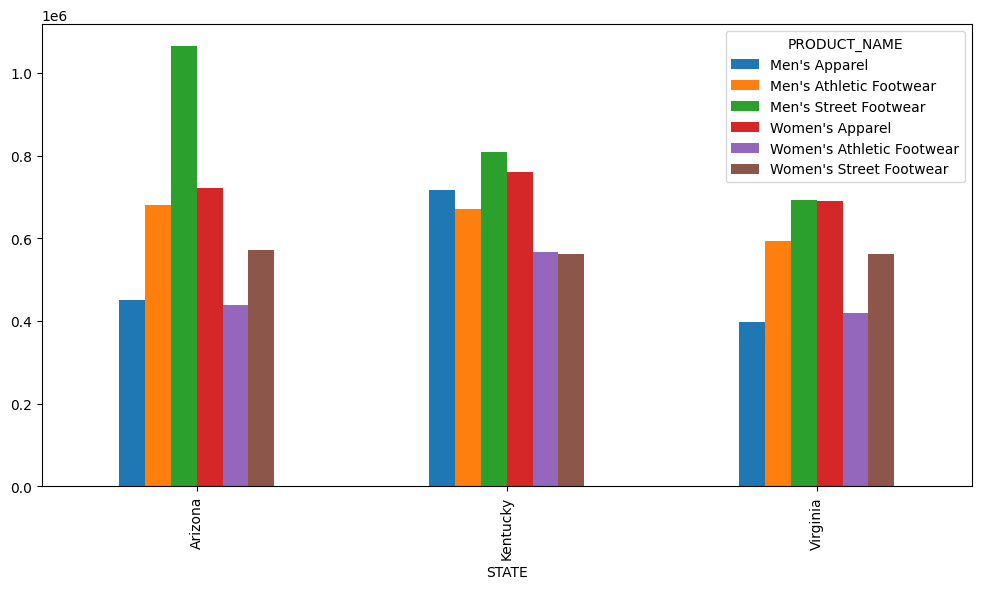

In [83]:
cat_by_warm_state.plot(kind='bar', figsize=(12, 6))
plt.show()